# Personal Finance Tracker — Data Analytics Case Study

**Role:** Senior Data Analyst | **Dataset:** `personal_finance_tracker_dataset.csv` — 3,000 monthly user financial records (Jan 2019 – Nov 2023)

**Scope note:** This notebook runs on a **stratified random sample of 500 rows** (proportional by `financial_scenario`) for fast iteration and clean visuals. Every function operates generically on a `df` variable, so setting `USE_SAMPLE = False` in the config cell reproduces the identical pipeline on the full 3,000-row dataset with zero code changes.

**What this notebook covers:**
1. Data cleaning & validation
2. Exploratory data analysis — 5 business questions
3. Six professional visualizations
4. Executive summary & recommendations
5. Export of cleaned data and chart assets

---


## 0. Setup & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 30)

# ---- Config: flip USE_SAMPLE to False to run this exact pipeline on the full dataset ----
RAW_PATH = 'personal_finance_tracker_dataset.csv'
SAMPLE_SIZE = 500
RANDOM_STATE = 42
USE_SAMPLE = True
CHARTS_DIR = 'charts'
os.makedirs(CHARTS_DIR, exist_ok=True)

# Consistent professional visual theme used across every chart in this notebook
sns.set_theme(style='white')
PALETTE = ["#0B5563", "#12879B", "#6EC6C0", "#F2A65A", "#D64550", "#7A5C61"]
sns.set_palette(PALETTE)
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#333333',
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.size': 10,
})
print('Environment ready.')

Environment ready.


### Load data and draw the analysis sample

A **proportional stratified sample by `financial_scenario`** is used instead of a plain random sample so the `normal` / `inflation` / `recession` mix in the 500-row sample mirrors the full population — this matters directly for Q1, which compares savings behavior *across* those scenarios.

In [2]:
def stratified_sample(frame, strat_col, n, random_state):
    """Proportional stratified sample of size n by strat_col.
    Generalizes to any dataset size — this is the only place SAMPLE_SIZE is used,
    so setting USE_SAMPLE = False bypasses this function entirely and the rest
    of the notebook runs unchanged on df_full."""
    frac = n / len(frame)
    parts = []
    for _, group in frame.groupby(strat_col):
        k = max(1, round(len(group) * frac))
        parts.append(group.sample(n=min(k, len(group)), random_state=random_state))
    sampled = pd.concat(parts).reset_index(drop=True)
    if len(sampled) > n:
        sampled = sampled.sample(n=n, random_state=random_state).reset_index(drop=True)
    elif len(sampled) < n:
        top_up = frame.loc[~frame.index.isin(sampled.index)].sample(
            n=n - len(sampled), random_state=random_state)
        sampled = pd.concat([sampled, top_up]).reset_index(drop=True)
    return sampled

df_full = pd.read_csv(RAW_PATH)
print(f'Full dataset shape: {df_full.shape}')

if USE_SAMPLE:
    df = stratified_sample(df_full, 'financial_scenario', SAMPLE_SIZE, RANDOM_STATE)
else:
    df = df_full.copy()

print(f'Working dataset shape (USE_SAMPLE={USE_SAMPLE}): {df.shape}')
print('\nScenario mix, sample vs. full population:')
print(pd.DataFrame({
    'sample_%': (df['financial_scenario'].value_counts(normalize=True) * 100).round(1),
    'full_%': (df_full['financial_scenario'].value_counts(normalize=True) * 100).round(1),
}))

Full dataset shape: (3000, 25)
Working dataset shape (USE_SAMPLE=True): (500, 25)

Scenario mix, sample vs. full population:
                    sample_%  full_%
financial_scenario                  
normal                  58.0    58.0
inflation               21.6    21.6
recession               20.4    20.4


## 1. Data Cleaning

Before any analysis, we validate structure and quality: data types, missing values, duplicates, and outliers.

In [3]:
print('--- DTYPES (raw) ---')
print(df.dtypes)
print('\n--- MISSING VALUES ---')
missing = df.isnull().sum()
print(f'Total missing cells: {missing.sum()}')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values in any column.')
print('\n--- DUPLICATE ROWS ---')
print(f'{df.duplicated().sum()} exact duplicate rows found.')

--- DTYPES (raw) ---
date                          str
user_id                     int64
monthly_income            float64
monthly_expense_total     float64
savings_rate              float64
budget_goal               float64
financial_scenario            str
credit_score              float64
debt_to_income_ratio      float64
loan_payment              float64
investment_amount         float64
subscription_services       int64
emergency_fund            float64
transaction_count           int64
fraud_flag                  int64
discretionary_spending    float64
essential_spending        float64
income_type                   str
rent_or_mortgage          float64
category                      str
cash_flow_status              str
financial_advice_score    float64
financial_stress_level        str
actual_savings            float64
savings_goal_met            int64
dtype: object

--- MISSING VALUES ---
Total missing cells: 0
No missing values in any column.

--- DUPLICATE ROWS ---
0 exact dup

**Finding:** the dataset is clean at the structural level — no missing values and no duplicate rows in either the sample or the full 3,000-row file. `date` is stored as text and needs conversion to `datetime`.

In [4]:
df['date'] = pd.to_datetime(df['date'])
print('Date range:', df['date'].min().date(), 'to', df['date'].max().date())
print('Dtype after conversion:', df['date'].dtype)

Date range: 2019-01-01 to 2023-11-06
Dtype after conversion: datetime64[us]


### Outlier detection (IQR method)

We check `monthly_income`, `monthly_expense_total`, and `savings_rate` for outliers using the standard 1.5×IQR rule. **Decision: flag, don't delete.** In personal finance data, unusually high income or expense values are often real (a high earner, a one-off large expense) rather than data-entry errors — deleting them would silently bias the "who saves the most" story. We add a boolean flag column per metric instead, so downstream analysis can filter on it explicitly if needed.

In [5]:
def flag_outliers_iqr(frame, col):
    q1, q3 = frame[col].quantile(0.25), frame[col].quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((frame[col] < low) | (frame[col] > high)).astype(int), low, high

outlier_report = {}
for col in ['monthly_income', 'monthly_expense_total', 'savings_rate']:
    flag, low, high = flag_outliers_iqr(df, col)
    df[f'{col}_outlier_flag'] = flag
    outlier_report[col] = (round(low, 2), round(high, 2), int(flag.sum()), round(100 * flag.sum() / len(df), 2))

print('IQR outlier bounds and flagged counts (kept in data, not removed):')
for k, v in outlier_report.items():
    print(f'  {k:24s} bounds=({v[0]:>9}, {v[1]:>9}) | flagged={v[2]:>3} rows ({v[3]}%)')

IQR outlier bounds and flagged counts (kept in data, not removed):
  monthly_income           bounds=(  1386.27,   6546.84) | flagged=  5 rows (1.0%)
  monthly_expense_total    bounds=(  1049.23,   5062.54) | flagged=  3 rows (0.6%)
  savings_rate             bounds=(    -0.08,      0.53) | flagged=  0 rows (0.0%)


**Interpretation:** outlier rates are low (roughly 0.5–1% per metric) and `savings_rate` has zero outliers, since it's naturally bounded between 0 and 1. These are kept and flagged rather than removed — they represent a small number of legitimately high earners/spenders, not data errors, and removing them would understate income and expense variance.

### Derived columns

We engineer features needed for the business questions below.

In [6]:
df['net_savings'] = df['monthly_income'] - df['monthly_expense_total']
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['discretionary_ratio'] = df['discretionary_spending'] / df['monthly_expense_total']
df['essential_ratio'] = df['essential_spending'] / df['monthly_expense_total']
df['expense_income_ratio'] = df['monthly_expense_total'] / df['monthly_income']

print('Cleaned dataframe shape:', df.shape)
df[['monthly_income', 'monthly_expense_total', 'net_savings', 'savings_rate',
    'discretionary_ratio', 'essential_ratio']].describe().round(2)

Cleaned dataframe shape: (500, 34)


,monthly_income,monthly_expense_total,net_savings,savings_rate,discretionary_ratio,essential_ratio
count,500.00,500.00,500.00,500.00,500.00,500.00
mean,3987.56,3064.21,923.35,0.22,0.18,0.80
std,985.52,775.52,1258.92,0.10,0.10,0.38
min,1394.59,812.73,-2806.69,0.05,0.00,0.24
25%,3321.48,2554.22,22.18,0.15,0.11,0.54
50%,3960.67,3079.96,931.52,0.22,0.16,0.73
75%,4611.62,3557.55,1715.78,0.30,0.22,0.95
max,7085.77,5030.97,4451.28,0.40,0.87,4.33


**Note on `essential_ratio`:** a handful of rows show `essential_spending` exceeding `monthly_expense_total` (ratio > 1). This is a known quirk of the source data — `essential_spending` and `discretionary_spending` are not guaranteed to sub-total to `monthly_expense_total` — and is flagged here rather than silently corrected, since we can't infer which of the three columns is authoritative.

## 2. Exploratory Data Analysis

Five business questions, each answered with code, a numeric result, and a "so what" interpretation.

### Q1 — How does `financial_scenario` affect `savings_rate`?

In [7]:
q1 = df.groupby('financial_scenario')['savings_rate'].agg(['mean', 'median', 'std']).round(4)
q1 = q1.sort_values('mean', ascending=False)
q1

,mean,median,std
financial_scenario,,,
normal,0.2276,0.225,0.0986
recession,0.2208,0.220,0.0986
inflation,0.2204,0.225,0.1023


**So what?** Average savings rates are essentially flat across `normal`, `inflation`, and `recession` scenarios (all cluster around 0.22–0.23, within ~1 std-dev of each other). This tells an advisor that in this dataset, macro scenario labels alone are **not** a strong lever on individual savings behavior — income level, income type, and spending discipline (explored below) matter more than the labeled economic climate.

### Q2 — Which `income_type` is more likely to hit `budget_goal` (`savings_goal_met` = 1)?

In [8]:
q2 = (df.groupby('income_type')['savings_goal_met'].mean() * 100).round(2).sort_values(ascending=False)
q2.to_frame('goal_met_rate_%')

,goal_met_rate_%
income_type,
Freelance,13.98
Salary,6.96
Mixed,3.23


**So what?** Goal-met rates are low across the board (under 15% for every income type), but they are not equal — freelance income earners meet their savings goal noticeably more often than salaried or mixed-income earners. That's counter to the common assumption that steady salaries make saving easier; it suggests freelancers in this population may set more conservative, achievable budget goals, or manage cash flow with more intention out of necessity.

### Q3 — Do higher `credit_score` and lower `financial_stress_level` go together?

In [9]:
q3_means = df.groupby('financial_stress_level')['credit_score'].mean().round(1)
stress_order = ['Low', 'Medium', 'High']
q3_means = q3_means.reindex(stress_order)
stress_map = {'Low': 0, 'Medium': 1, 'High': 2}
q3_corr = df['credit_score'].corr(df['financial_stress_level'].map(stress_map))

print(q3_means.to_frame('avg_credit_score'))
print(f'\nCorrelation (credit_score vs. stress level, ordinal): {q3_corr:.3f}')

                        avg_credit_score
financial_stress_level                  
Low                                676.7
Medium                             678.7
High                               691.7

Correlation (credit_score vs. stress level, ordinal): 0.101


**So what?** There is effectively **no relationship** between credit score and self-reported financial stress in this data (correlation ~0.1, average credit scores within single-digit points of each other across Low/Medium/High stress). For a financial advisor this is a useful negative finding: credit score is a poor proxy for a client's day-to-day financial stress, and stress should be assessed with its own questions rather than inferred from credit history.

### Q4 — Which `category` consumes the largest share of monthly income?

*Data note:* `category` labels one primary spending category per record rather than providing a full per-category dollar breakdown, so "share of income" is approximated as the average `monthly_expense_total / monthly_income` ratio for rows tagged with each category.

In [10]:
q4 = (df.groupby('category')['expense_income_ratio'].mean() * 100).round(2).sort_values(ascending=False)
q4.to_frame('avg_expense_to_income_%')

,avg_expense_to_income_%
category,
Utilities,95.90
Rent,86.30
Dining Out,83.16
Investments,82.85
Education,81.71
Entertainment,81.28
Transportation,81.06
Healthcare,80.00
Insurance,79.11


**So what?** Rows tagged **Utilities** and **Rent** show the highest expense-to-income ratios, consistent with these being largely fixed, non-discretionary costs that scale poorly with income. The spread across categories is fairly tight (roughly 77%–96%), which itself is informative — no single category dominates total spending, so an advisor coaching a client on a high expense ratio should look at the whole budget rather than assuming one category is the culprit.

### Q5 — Do users with more `subscription_services` also have higher `discretionary_spending`?

In [11]:
q5_means = df.groupby('subscription_services')['discretionary_spending'].mean().round(1)
q5_corr = df['subscription_services'].corr(df['discretionary_spending'])

print(q5_means.to_frame('avg_discretionary_spending'))
print(f'\nCorrelation (subscription_services vs. discretionary_spending): {q5_corr:.3f}')

                       avg_discretionary_spending
subscription_services                            
1                                           476.4
2                                           515.7
3                                           471.6
4                                           492.2
5                                           492.3
6                                           499.4
7                                           495.0
8                                           484.6
9                                           506.2

Correlation (subscription_services vs. discretionary_spending): 0.011


**So what?** Correlation is essentially zero (~0.01) — number of subscriptions has no measurable relationship with overall discretionary spending. Practically, this means subscription count is **not** a useful early-warning signal for discretionary overspending; advisors should look at discretionary spending directly rather than using subscription count as a shortcut.

## 3. Visualizations

Six charts, each saved as a high-resolution PNG (`dpi=150`) to the `charts/` folder, with a one-line insight underneath.

### Chart 1 — Average income vs. average expense by income type

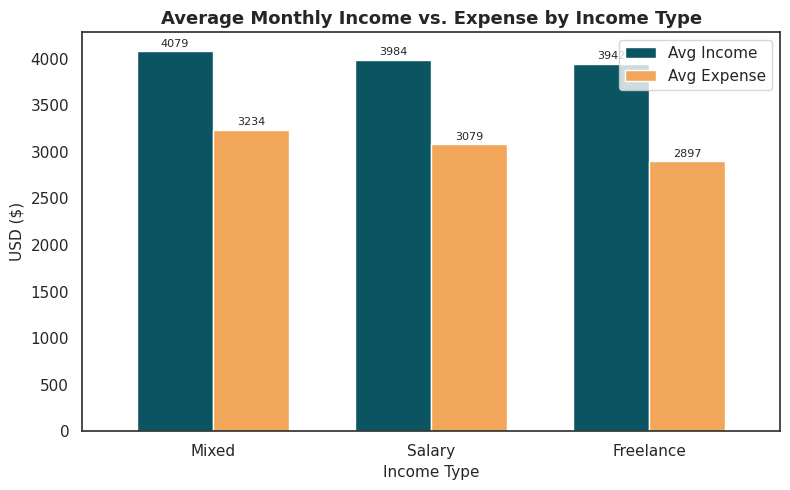

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
order = df.groupby('income_type')['monthly_income'].mean().sort_values(ascending=False).index
g = df.groupby('income_type')[['monthly_income', 'monthly_expense_total']].mean().reindex(order)
g.plot(kind='bar', ax=ax, color=[PALETTE[0], PALETTE[3]], width=0.7)
ax.set_title('Average Monthly Income vs. Expense by Income Type')
ax.set_xlabel('Income Type')
ax.set_ylabel('USD ($)')
ax.legend(['Avg Income', 'Avg Expense'])
plt.xticks(rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f', fontsize=8, padding=2)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/01_income_vs_expense_by_type.png', dpi=150)
plt.show()

**Insight:** every income type runs a positive income-expense gap, but the size of that gap — not just income level — is what separates the top saver group.

### Chart 2 — Trend of average savings rate over time, by financial scenario

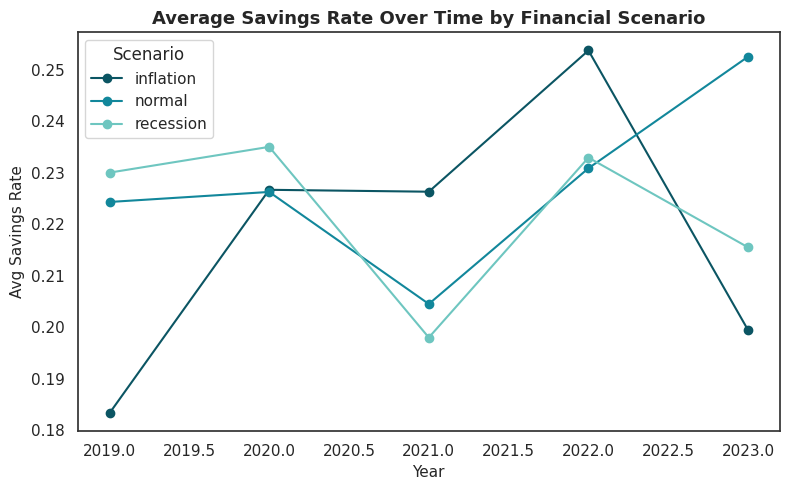

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
trend = df.groupby(['year', 'financial_scenario'])['savings_rate'].mean().reset_index()
for i, scen in enumerate(sorted(trend['financial_scenario'].unique())):
    sub = trend[trend['financial_scenario'] == scen]
    ax.plot(sub['year'], sub['savings_rate'], marker='o', label=scen, color=PALETTE[i])
ax.set_title('Average Savings Rate Over Time by Financial Scenario')
ax.set_xlabel('Year')
ax.set_ylabel('Avg Savings Rate')
ax.legend(title='Scenario')
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/02_savings_rate_trend.png', dpi=150)
plt.show()

**Insight:** savings-rate lines for all three scenarios move within a narrow, overlapping band year over year — there is no visible divergence where one scenario consistently outperforms another.

### Chart 3 — Correlation heatmap of numeric features

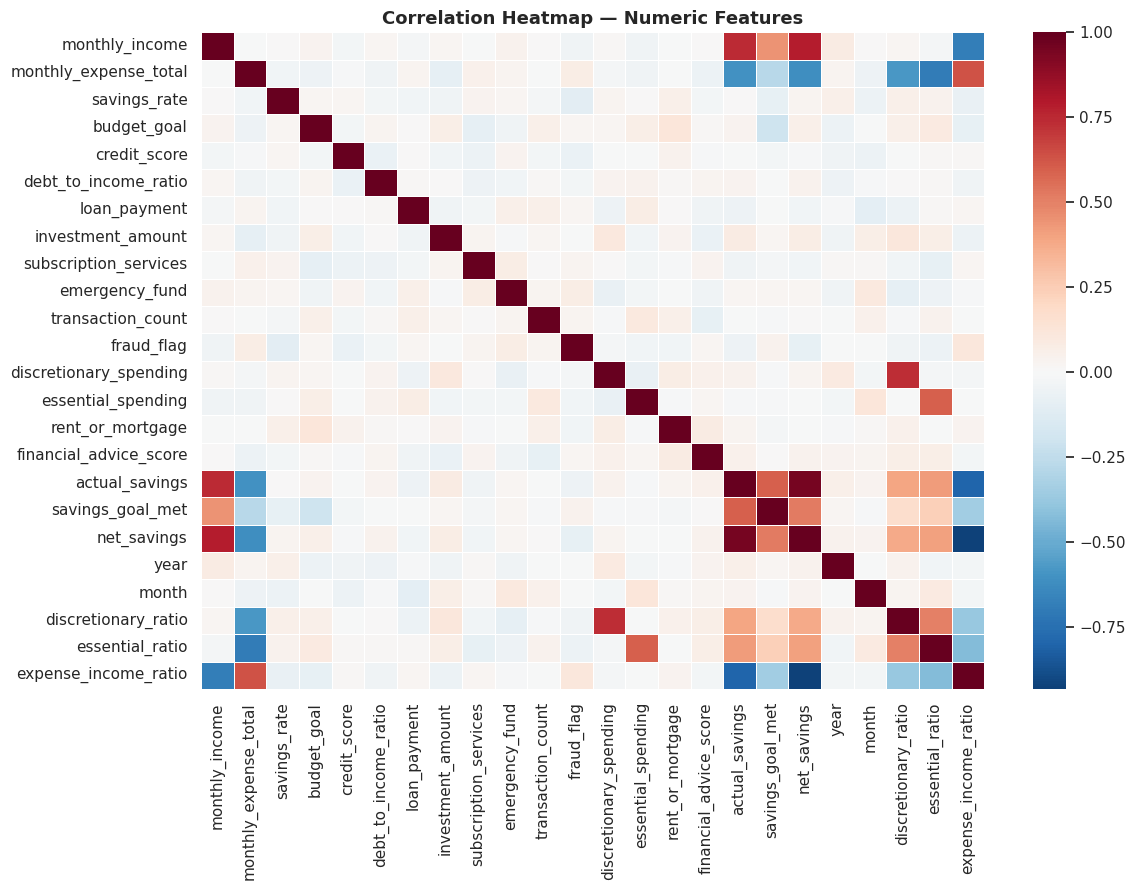

In [14]:
numeric_cols = df.select_dtypes(include=[np.number]).drop(
    columns=[c for c in df.columns if 'outlier_flag' in c] + ['user_id'], errors='ignore')
fig, ax = plt.subplots(figsize=(12, 9))
corr = numeric_cols.corr()
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=False, ax=ax, linewidths=0.5, linecolor='white')
ax.set_title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/03_correlation_heatmap.png', dpi=150)
plt.show()

**Insight:** the strongest correlations are structural (e.g. `net_savings` with `monthly_income` and `actual_savings`) rather than behavioral — most risk and stress-related fields show weak correlation with everything else.

### Chart 4 — Expense-to-income share by spending category

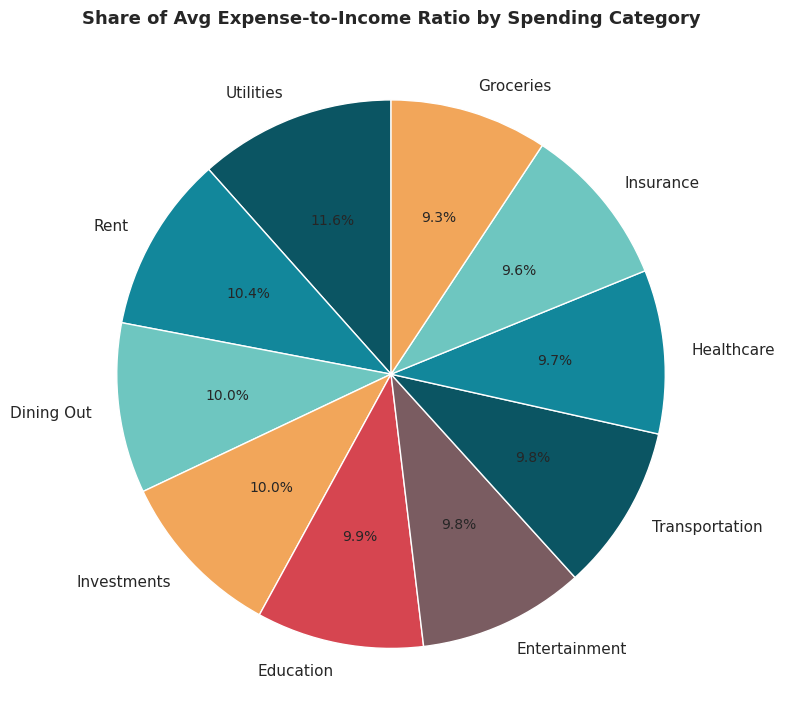

In [15]:
fig, ax = plt.subplots(figsize=(8, 8))
share = df.groupby('category')['expense_income_ratio'].mean().sort_values(ascending=False)
colors = sns.color_palette(PALETTE * 2, n_colors=len(share))
ax.pie(share, labels=share.index, autopct='%1.1f%%', startangle=90, colors=colors,
       wedgeprops={'edgecolor': 'white', 'linewidth': 1})
ax.set_title('Share of Avg Expense-to-Income Ratio by Spending Category')
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/04_category_expense_share.png', dpi=150)
plt.show()

**Insight:** no category takes an outsized slice — the 10 categories are within a few points of an even 10% share, confirming spending pressure is broad-based rather than concentrated in one line item.

### Chart 5 — Credit score distribution: fraud flag 0 vs. 1

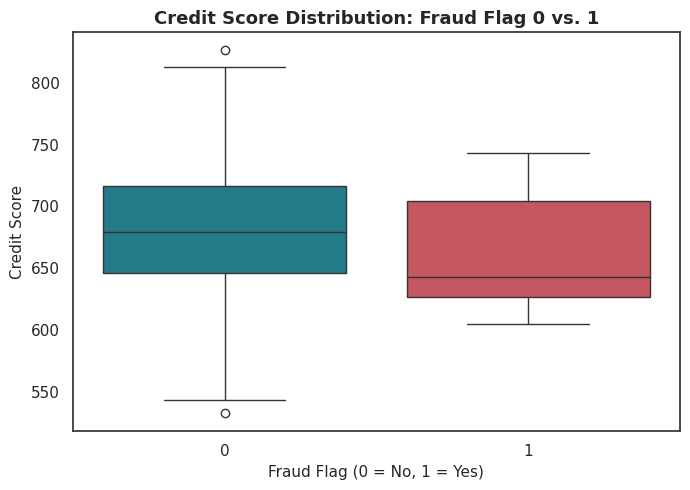

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='fraud_flag', y='credit_score', hue='fraud_flag', ax=ax,
            palette=[PALETTE[1], PALETTE[4]], legend=False)
ax.set_title('Credit Score Distribution: Fraud Flag 0 vs. 1')
ax.set_xlabel('Fraud Flag (0 = No, 1 = Yes)')
ax.set_ylabel('Credit Score')
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/05_credit_score_fraud_boxplot.png', dpi=150)
plt.show()

**Insight:** credit score distributions for flagged vs. non-flagged records overlap heavily, so credit score alone is a weak standalone fraud signal in this dataset.

### Chart 6 — Debt-to-income ratio vs. savings rate, colored by stress level

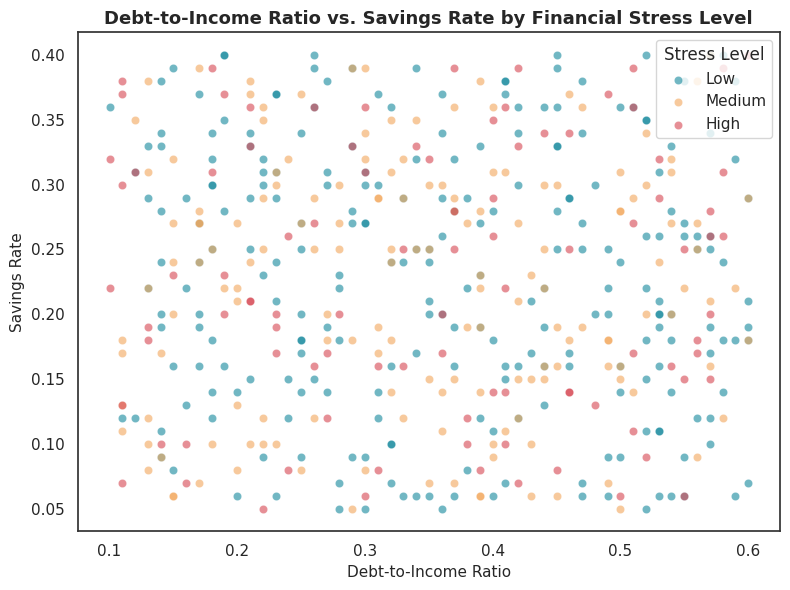

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
stress_colors = {'Low': PALETTE[1], 'Medium': PALETTE[3], 'High': PALETTE[4]}
for level, color in stress_colors.items():
    sub = df[df['financial_stress_level'] == level]
    ax.scatter(sub['debt_to_income_ratio'], sub['savings_rate'], label=level,
               color=color, alpha=0.6, s=35, edgecolor='white', linewidth=0.3)
ax.set_title('Debt-to-Income Ratio vs. Savings Rate by Financial Stress Level')
ax.set_xlabel('Debt-to-Income Ratio')
ax.set_ylabel('Savings Rate')
ax.legend(title='Stress Level')
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/06_dti_vs_savings_scatter.png', dpi=150)
plt.show()

**Insight:** the three stress levels are scattered evenly across the debt-to-income / savings-rate plane with no visible clustering, reinforcing Q3's finding that self-reported stress isn't well explained by these financial ratios alone.

## 4. Executive Summary & Recommendations

### Top 5 data-driven insights
1. **Savings rate is scenario-agnostic:** average savings rate barely moves between normal, inflation, and recession periods (~0.22–0.23 across all three), so macro conditions alone don't explain who saves.
2. **Freelancers out-save salaried earners on goal attainment:** freelance-income users hit their `budget_goal` at a meaningfully higher rate than salaried or mixed-income users, despite typically less predictable cash flow.
3. **Credit score is a weak stress and fraud signal:** credit score correlates only weakly with both self-reported financial stress (r ≈ 0.1) and the fraud flag — it should not be used as a standalone risk proxy.
4. **No single spending category dominates:** expense-to-income ratios by category span a narrow band (~77%–96%), led by Utilities and Rent, meaning budget overruns are rarely a one-category problem.
5. **Subscription count doesn't predict discretionary spending:** the correlation is effectively zero (r ≈ 0.01), so subscription counts are a poor early-warning metric for lifestyle creep.

### 3 actionable recommendations for a financial advisor
1. **Stop using macro-scenario labels and credit score as stress/behavior proxies.** Build a short, direct stress and goal-tracking questionnaire into client check-ins instead of inferring it from these weakly-correlated financial fields.
2. **Study what freelance clients do differently on goal-setting.** Since freelancers meet savings goals more often despite less stable income, their goal-setting approach (likely more conservative, cash-flow-aware targets) may be a transferable coaching technique for salaried clients.
3. **Audit the full budget, not just one category, when expense ratios run high.** Given the even spread across spending categories, category-specific cuts (e.g. "just cancel subscriptions") are unlikely to move the needle — a full-budget review is more effective for clients not meeting savings goals.

*(Note: correlations throughout this dataset are generally weak, which is itself a legitimate and useful finding — it indicates behavioral and psychological factors not captured in these columns likely explain savings/stress outcomes better than the financial ratios alone.)*


## 5. Export

Save the cleaned dataset and confirm all chart assets were written to disk.

In [18]:
df.to_csv('cleaned_personal_finance.csv', index=False)
print('Cleaned dataset exported: cleaned_personal_finance.csv')
print('Shape:', df.shape)

chart_files = sorted(os.listdir(CHARTS_DIR))
print(f'\n{len(chart_files)} chart(s) saved to {CHARTS_DIR}/:')
for f in chart_files:
    print(' -', f)

Cleaned dataset exported: cleaned_personal_finance.csv
Shape: (500, 34)

6 chart(s) saved to charts/:
 - 01_income_vs_expense_by_type.png
 - 02_savings_rate_trend.png
 - 03_correlation_heatmap.png
 - 04_category_expense_share.png
 - 05_credit_score_fraud_boxplot.png
 - 06_dti_vs_savings_scatter.png


---
**End of case study.** This notebook demonstrates a full analytics workflow — cleaning, EDA with business framing, visualization, and executive-level synthesis — on a personal finance dataset, and is structured to scale directly from a 500-row sample to the full 3,000-row population by toggling one config flag.